# Boundary-Charge Method (BCM) for Spherical Nanoparticles — `bcm_sphere.py`

The BCM is a semi-analytical method that expands the electromagnetic response
of a spherical nanoparticle in vector spherical harmonics up to order $\ell_{\max}$.
It handles single spheres and arbitrarily large clusters through a block linear system.

## What it computes

- Absorption efficiency $Q_{\rm abs}(\omega)$ and scattering $Q_{\rm sca}(\omega)$
- Internal field expansion coefficients $X_{\ell m}(\omega)$ for each sphere
- Per-sphere power in a multi-particle cluster

## Core objects

| Object / Function | Role |
|---|---|
| `EField` | Incident plane wave: amplitude $E_0$, direction $\hat{k}$, polarisation $\hat{e}$ |
| `BCMObject` | One sphere: diameter, position, $\ell_{\max}$, permittivity function $\varepsilon(\lambda)$ |
| `Ginternal(obj)` | Self-interaction matrix (geometry only, frequency-independent) |
| `Gexternal(obj_i, obj_j)` | Inter-sphere coupling matrix (geometry only) |
| `Efield_coupling(obj, field)` | Project incident field onto sphere multipoles |
| `solve_BCM(w, eps_h, ...)` | Solve the linear system at one frequency |
| `EM_power(w, eps_h, ...)` | Compute $P_{\rm abs}$, $P_{\rm sca}$ over a full frequency axis |
| `run_optical_response(config)` | All-in-one convenience wrapper |

## Why $X_{\ell m}$ matters

The BCM coefficients $X_{\ell m}(\omega)$ encode the **internal EM field** of each sphere.
They are the direct input to `hot_carriers.hot_e_dist` and `HC_spatial`,
connecting the optical response to the hot-carrier generation pipeline.


## Step 0 - Imports and built-in material databases


In [1]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import hbar as hbar_si, eV as eV_si, physical_constants
from scipy.signal import find_peaks

import plytrons.bcm_sphere as bcm
from plytrons.bcm_sphere import EField, BCMObject, MATERIAL_PARAMS, MEDIA

from numba.core.errors import NumbaTypeSafetyWarning
warnings.simplefilter('ignore', category=NumbaTypeSafetyWarning)

# Free-space impedance in project units [e V^-1 s^-1]
Z0_si, *_ = physical_constants["characteristic impedance of vacuum"]
Z0 = Z0_si * eV_si

# ---- Built-in databases -----------------------------------------------
print("Built-in material parameters (MATERIAL_PARAMS):")
for mat, p in MATERIAL_PARAMS.items():
    print(f"  {mat:8s}  wp={p['wp']:.2f} eV  eps_b={p['eps_b']:.2f}  "
          f"gamma0={p['gamma0']:.3f} eV  EF={p['EF']:.2f} eV")

print()
print("Built-in host media (MEDIA):")
for name, eps in MEDIA.items():
    print(f"  {name:20s}  eps_h = {eps}")


Built-in material parameters (MATERIAL_PARAMS):
  Silver    wp=9.07 eV  eps_b=4.18  gamma0=0.060 eV  EF=5.53 eV
  Gold      wp=9.03 eV  eps_b=9.84  gamma0=0.070 eV  EF=5.53 eV
  Copper    wp=8.80 eV  eps_b=1.00  gamma0=0.027 eV  EF=7.00 eV

Built-in host media (MEDIA):
  Vacuum / Air          eps_h = 1.0
  Water                 eps_h = 1.77
  Glass (SiO₂)          eps_h = 2.25
  TiO₂                  eps_h = 6.25


---
## Step 1 - Single sphere: the complete BCM pipeline

We solve the optical response of a single silver nanosphere step by step.

### Pipeline overview

```
1. Define geometry + field   (EField, BCMObject)
2. Compute matrices           Ginternal, Gexternal, Efield_coupling  [once, freq-independent]
3. Frequency loop             solve_BCM at each omega
4. Store coefficients         obj.set_coefficients(lam_um, coef)
5. Compute power              EM_power  ->  Pabs, Psca
6. Access X_lm at peak        obj.coef_at(lam_peak)
```

The geometry matrices (step 2) depend only on sphere positions and multipole
truncation — they do not change with frequency and are therefore computed once.


In [2]:
# ---- Material: Silver Drude ------------------------------------------
p = MATERIAL_PARAMS['Silver']
wp_rad = p['wp']  * eV_si / hbar_si   # [rad/s]
gw_rad = p['gamma0'] * eV_si / hbar_si
eps_b  = p['eps_b']

def eps_drude(lam_um):
    """Drude permittivity, lambda in um."""
    omega = 2 * np.pi * 3e14 / lam_um   # [rad/s]
    return eps_b - wp_rad**2 / (omega * (omega + 1j * gw_rad))

# ---- Geometry ---------------------------------------------------------
D     = 10.0    # diameter [nm]
a     = D / 2   # radius   [nm]
lmax  = 8       # multipole truncation
eps_h = 1.0     # host: vacuum

sphere = BCMObject(label='Sphere1', diameter=D, lmax=lmax,
                   eps=eps_drude, position=np.array([0.0, 0.0, 0.0]))

# ---- Incident field (x-polarised, propagation along z) ---------------
efield = EField(E0=1.0,
                k_hat=bcm.v_normalize([0, 0, 1]),
                e_hat=bcm.v_normalize([1, 0, 0]))

print(f'Sphere: D = {D} nm,  lmax = {lmax}')
print(f'Field:  E || {bcm.get_axis(efield.e_hat)},  k || {bcm.get_axis(efield.k_hat)}')
print(f'n_coef per sphere = {sphere.n_coef}  (= lmax*(lmax+2) = {lmax}*{lmax+2})')


Sphere: D = 10.0 nm,  lmax = 8
Field:  E || x,  k || z
n_coef per sphere = 80  (= lmax*(lmax+2) = 8*10)


c:\users\pablo\proyectos\plytrons\plytrons\bcm_sphere.py:251: RuntimeWarning: invalid value encountered in true_divide
  vector = np.array(vector) / np.array(vector)


In [3]:
# ---- Frequency axis --------------------------------------------------
w       = np.linspace(2.5, 4.5, 3000) * eV_si / hbar_si   # [rad/s]
lam_um  = 2 * np.pi * 3e14 / w                             # [um]
hv_axis = w * hbar_si / eV_si                               # [eV]

BCM_objects = [sphere]
Np          = 1

# ---- Geometry matrices (computed once) --------------------------------
Gi = [bcm.Ginternal(obj) for obj in BCM_objects]
G0 = [[bcm.Gexternal(BCM_objects[i], BCM_objects[j]) for j in range(Np)]
       for i in range(Np)]
Sv = [bcm.Efield_coupling(obj, efield) for obj in BCM_objects]

# ---- Frequency loop ---------------------------------------------------
dx_max = lmax * (lmax + 1) + (lmax + 1) - 1   # = lmax*(lmax+2)
coef   = np.zeros((dx_max, len(w)), dtype=complex)

for il, wi in enumerate(w):
    c, _ = bcm.solve_BCM(wi, eps_h, BCM_objects, efield, Gi, G0, Sv)
    coef[:, il] = c[0]

# ---- Store coefficients and compute power -----------------------------
sphere.set_coefficients(lam_um, coef)
_, Pabs = bcm.EM_power(w, eps_h, Gi, G0, BCM_objects)

print('Sweep complete.')
print(f'coef shape: {coef.shape}  = (n_modes, n_freq)')
print(f'Pabs shape: {Pabs[0].shape}  = (n_freq,)')


Sweep complete.
coef shape: (80, 3000)  = (n_modes, n_freq)
Pabs shape: (3000,)  = (n_freq,)


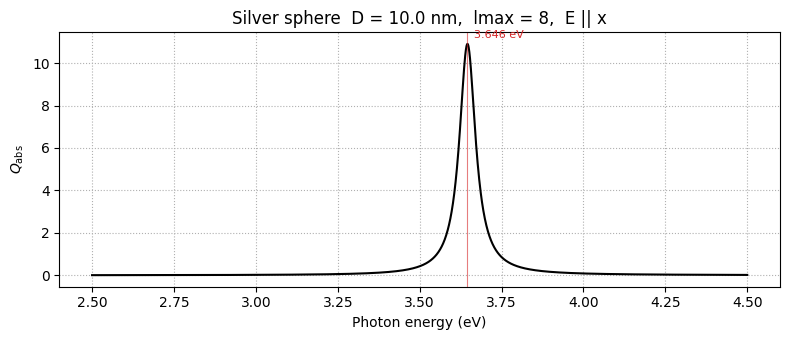

Main resonance:  hv = 3.646 eV  (lambda = 340.3 nm)


In [4]:
# ---- Absorption efficiency Q_abs = P_abs / (I0 * pi*R^2) ------------
I0   = efield.E0**2 / (2 * Z0)
Qabs = Pabs[0] / I0 / (np.pi * a**2)

peaks_idx, _ = find_peaks(Qabs, height=0.05 * Qabs.max(), prominence=0.01)
pk_main      = peaks_idx[np.argmax(Qabs[peaks_idx])] if len(peaks_idx) else Qabs.argmax()

hv_peak  = hv_axis[pk_main]
lam_peak = lam_um[pk_main]

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(hv_axis, Qabs, 'k', lw=1.5)
for pk in peaks_idx:
    ax.axvline(hv_axis[pk], lw=0.8, color='C3', alpha=0.6)
    ax.annotate(f'{hv_axis[pk]:.3f} eV',
                xy=(hv_axis[pk], Qabs[pk]),
                xytext=(5, 4), textcoords='offset points', fontsize=8, color='C3')

ax.set_xlabel('Photon energy (eV)')
ax.set_ylabel(r'$Q_{\rm abs}$')
ax.set_title(f'Silver sphere  D = {D} nm,  lmax = {lmax},  E || x')
ax.grid(True, ls=':')
plt.tight_layout()
plt.show()

print(f'Main resonance:  hv = {hv_peak:.3f} eV  (lambda = {lam_peak*1e3:.1f} nm)')


---
## Step 2 - EM multipole coefficients $X_{\ell m}$

At each frequency, `solve_BCM` returns the expansion coefficients $X_{\ell m}$
of the **internal EM field** inside the sphere in the vector spherical harmonic basis.

- Index into the $X_{\ell m}$ array: $k(\ell, m) = (\ell-1)(\ell+1) + (m + \ell)$
- Dominant $\ell = 1$: dipole mode (small spheres, long wavelength)
- Higher $\ell$: quadrupole, octupole, ... (larger spheres or short wavelength)

### Polarisation selection rules

| Polarisation | Excited $m$ values | Angular pattern |
|---|---|---|
| $E \parallel x$ | $m = \pm 1$ | Equatorial $|Y_{\ell,\pm 1}(\theta)|^2 \propto \sin^2\theta$ |
| $E \parallel z$ | $m = 0$ | Polar $|Y_{\ell 0}(\theta)|^2 \propto \cos^2\theta$ |

This is directly visible in the $X_{\ell m}$ coefficients.


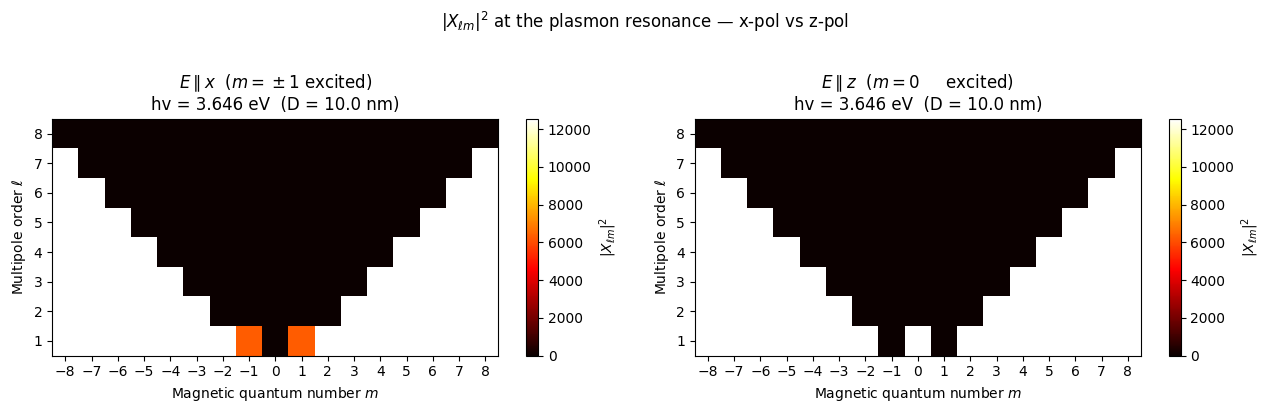

Per-l power  |X_l|^2 = sum_m |X_lm|^2  (x-pol):
  l=1:  1.255e+04
  l=3:  4.925e-15
  l=5:  7.222e-15
  l=7:  1.089e-14


In [5]:
# ---- X_lm at the resonance for x-polarisation (already computed) ----
X_lm_x = coef[:, pk_main]

# ---- Solve for z-polarisation at peak frequency only -----------------
efield_z = EField(E0=1.0, k_hat=bcm.v_normalize([1, 0, 0]),
                  e_hat=bcm.v_normalize([0, 0, 1]))
Sv_z = [bcm.Efield_coupling(sphere, efield_z)]
c_z, _ = bcm.solve_BCM(w[pk_main], eps_h, BCM_objects, efield_z, Gi, G0, Sv_z)
X_lm_z = c_z[0]

# ---- Build (l, m) index map ------------------------------------------
def xlm_to_2d(X_lm, lmax):
    """Map X_lm vector to 2-D array indexed by [l-1, m+lmax]."""
    arr = np.full((lmax, 2 * lmax + 1), np.nan)
    for l in range(1, lmax + 1):
        for m in range(-l, l + 1):
            idx = (l - 1) * (l + 1) + (m + l)
            if idx < len(X_lm):
                arr[l - 1, m + lmax] = np.abs(X_lm[idx])**2
    return arr

grid_x = xlm_to_2d(X_lm_x, lmax)
grid_z = xlm_to_2d(X_lm_z, lmax)
vmax   = max(np.nanmax(grid_x), np.nanmax(grid_z))

m_ticks = np.arange(-lmax, lmax + 1)
l_ticks = np.arange(1, lmax + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, grid, pol_label in [
        (axes[0], grid_x, r'$E \parallel x$  ($m = \pm 1$ excited)'),
        (axes[1], grid_z, r'$E \parallel z$  ($m = 0$     excited)'),
    ]:
    im = ax.pcolormesh(m_ticks, l_ticks, grid, cmap='hot', vmin=0, vmax=vmax,
                       shading='nearest')
    plt.colorbar(im, ax=ax, label=r'$|X_{\ell m}|^2$')
    ax.set_xlabel('Magnetic quantum number $m$')
    ax.set_ylabel('Multipole order $\ell$')
    ax.set_xticks(range(-lmax, lmax + 1, 1))
    ax.set_yticks(l_ticks)
    ax.set_title(f'{pol_label}\nhv = {hv_peak:.3f} eV  (D = {D} nm)')

fig.suptitle(r'$|X_{\ell m}|^2$ at the plasmon resonance — x-pol vs z-pol', y=1.02)
plt.tight_layout()
plt.show()

# Per-l totals
print('Per-l power  |X_l|^2 = sum_m |X_lm|^2  (x-pol):')
for l in range(1, lmax + 1):
    row = grid_x[l - 1, :]
    tot = np.nansum(row)
    if tot > 1e-20:
        print(f'  l={l}:  {tot:.4g}')


---
## Step 3 - Accessing $X_{\ell m}$ at an arbitrary wavelength

After calling `set_coefficients`, you can retrieve the coefficients at any
wavelength inside the swept range using `obj.coef_at(lam_um)`.

This is how the hot-carrier pipeline accesses the EM field for each resonance:

```python
X_lm = sphere.coef_at(lam_peak)   # coefficients at peak wavelength
# Then pass to:
Te, Th, ... = hot_e_dist(a, hv_peak, EF, tau_e, e_states, X_lm, Pabs_peak)
```


In [6]:
# coef_at returns the complex X_lm vector at a given wavelength [um]
X_lm_interp = sphere.coef_at(lam_peak)

print(f'lam_peak = {lam_peak:.4f} um')
print(f'X_lm shape: {X_lm_interp.shape}  (= n_coef = lmax*(lmax+2))')
print()
print('Largest five coefficients |X_lm|^2:')
abs2 = np.abs(X_lm_interp)**2
top5 = np.argsort(abs2)[::-1][:5]
for rank, k in enumerate(top5, 1):
    # Decode index k -> (l, m)
    l = int(np.floor(np.sqrt(k + 1) - 1)) + 1
    m = k - (l - 1) * (l + 1) - l
    print(f'  rank {rank}:  (l={l}, m={m:+d})  |X_lm|^2 = {abs2[k]:.4g}')


lam_peak = 0.3403 um
X_lm shape: (80,)  (= n_coef = lmax*(lmax+2))

Largest five coefficients |X_lm|^2:
  rank 1:  (l=1, m=-1)  |X_lm|^2 = 1.228
  rank 2:  (l=1, m=+1)  |X_lm|^2 = 1.228
  rank 3:  (l=7, m=+1)  |X_lm|^2 = 2.155e-16
  rank 4:  (l=7, m=-1)  |X_lm|^2 = 2.155e-16
  rank 5:  (l=5, m=-1)  |X_lm|^2 = 1.142e-16


---
## Step 4 - Size dependence: $Q_{\rm abs}(\omega, D)$

We sweep the sphere diameter from 2 to 20 nm and track how the plasmon resonance
evolves. As $D$ increases:

1. The peak red-shifts (retardation and higher-order multipoles become important)
2. Scattering increases relative to absorption (radiation damping)
3. The peak broadens (larger radiative decay rate)


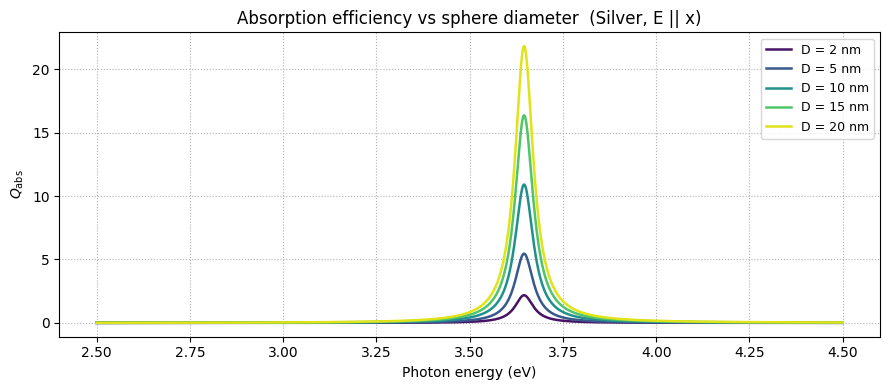

Peak positions:
  D =    2 nm:  3.646 eV
  D =    5 nm:  3.646 eV
  D =   10 nm:  3.646 eV
  D =   15 nm:  3.646 eV
  D =   20 nm:  3.646 eV


In [7]:
D_list  = [2, 5, 10, 15, 20]
colors  = plt.cm.viridis(np.linspace(0.05, 0.95, len(D_list)))

w_sw    = np.linspace(2.5, 4.5, 2000) * eV_si / hbar_si
lam_sw  = 2 * np.pi * 3e14 / w_sw
hv_sw   = w_sw * hbar_si / eV_si

fig, ax = plt.subplots(figsize=(9, 4))

peak_hv = []
for D_val, col in zip(D_list, colors):
    a_val = D_val / 2.0
    lmax_val = 6 if D_val <= 10 else 8

    sp = BCMObject(label='sp', diameter=D_val, lmax=lmax_val,
                   eps=eps_drude, position=np.array([0., 0., 0.]))

    Gi_sw = [bcm.Ginternal(sp)]
    G0_sw = [[bcm.Gexternal(sp, sp)]]
    Sv_sw = [bcm.Efield_coupling(sp, efield)]

    dx_sw  = lmax_val * (lmax_val + 1) + (lmax_val + 1) - 1
    coef_sw = np.zeros((dx_sw, len(w_sw)), dtype=complex)
    for il, wi in enumerate(w_sw):
        c, _ = bcm.solve_BCM(wi, eps_h, [sp], efield, Gi_sw, G0_sw, Sv_sw)
        coef_sw[:, il] = c[0]

    sp.set_coefficients(lam_sw, coef_sw)
    _, Pabs_sw = bcm.EM_power(w_sw, eps_h, Gi_sw, G0_sw, [sp])

    Qabs_sw = Pabs_sw[0] / I0 / (np.pi * a_val**2)
    ax.plot(hv_sw, Qabs_sw, color=col, lw=1.8, label=f'D = {D_val} nm')

    pks, _ = find_peaks(Qabs_sw, height=0.05 * Qabs_sw.max())
    if len(pks):
        peak_hv.append(hv_sw[pks[np.argmax(Qabs_sw[pks])]])
    else:
        peak_hv.append(np.nan)

ax.set_xlabel('Photon energy (eV)')
ax.set_ylabel(r'$Q_{\rm abs}$')
ax.set_title('Absorption efficiency vs sphere diameter  (Silver, E || x)')
ax.legend(fontsize=9)
ax.grid(True, ls=':')
plt.tight_layout()
plt.show()

print('Peak positions:')
for D_val, hv_pk in zip(D_list, peak_hv):
    print(f'  D = {D_val:>4} nm:  {hv_pk:.3f} eV')


---
## Step 5 - Dimer: coupled spheres

Two identical silver spheres along the z-axis with gap $\delta = 1$ nm.

Coupling between the two spheres is mediated by the off-diagonal blocks
$G^{\rm ext}_{12}$ and $G^{\rm ext}_{21}$ in the BCM system. These are
geometry matrices that do not depend on frequency.

Two polarisation cases:
- **Longitudinal** ($E \parallel z$, along dimer axis): large red shift,
  gap-concentrated near-field, bonding bright mode.
- **Transverse** ($E \perp z$): slight blue shift, weaker coupling.

The per-sphere absorption verifies the inversion symmetry of the homodimer:
$P_{\rm abs}^{(1)} = P_{\rm abs}^{(2)}$.


In [8]:
D_dim   = 5.0
a_dim   = D_dim / 2
gap_dim = 1.0
d_c     = D_dim + gap_dim
lmax_d  = 8
eps_h_d = 1.0

def eps_drude_d(lam_um):
    omega = 2 * np.pi * 3e14 / lam_um
    return eps_b - wp_rad**2 / (omega * (omega + 1j * gw_rad))

sp1 = BCMObject(label='Sp1', diameter=D_dim, lmax=lmax_d,
                eps=eps_drude_d, position=np.array([0., 0.,  d_c/2]))
sp2 = BCMObject(label='Sp2', diameter=D_dim, lmax=lmax_d,
                eps=eps_drude_d, position=np.array([0., 0., -d_c/2]))
dimer = [sp1, sp2]

# Fields
ef_long  = EField(E0=1., k_hat=bcm.v_normalize([1,0,0]),
                  e_hat=bcm.v_normalize([0,0,1]))  # E || z (longitudinal)
ef_trans = EField(E0=1., k_hat=bcm.v_normalize([1,0,0]),
                  e_hat=bcm.v_normalize([0,1,0]))  # E || y (transverse)

# Frequency axis (wider range to catch bonding mode red-shift)
w_d    = np.linspace(1.5, 5.5, 3000) * eV_si / hbar_si
lam_d  = 2 * np.pi * 3e14 / w_d
hv_d   = w_d * hbar_si / eV_si

# Geometry matrices (once)
Gi_d = [bcm.Ginternal(obj) for obj in dimer]
G0_d = [[bcm.Gexternal(dimer[i], dimer[j]) for j in range(2)] for i in range(2)]
dx_d = lmax_d * (lmax_d + 1) + (lmax_d + 1) - 1

# Solve longitudinal
Sv_l    = [bcm.Efield_coupling(obj, ef_long) for obj in dimer]
coef_l  = [np.zeros((dx_d, len(w_d)), dtype=complex) for _ in range(2)]
for il, wi in enumerate(w_d):
    c, _ = bcm.solve_BCM(wi, eps_h_d, dimer, ef_long, Gi_d, G0_d, Sv_l)
    coef_l[0][:, il] = c[0];  coef_l[1][:, il] = c[1]
for i in range(2):
    dimer[i].set_coefficients(lam_d, coef_l[i])
_, Pabs_l = bcm.EM_power(w_d, eps_h_d, Gi_d, G0_d, dimer)
print('Longitudinal done.')

# Solve transverse
Sv_t    = [bcm.Efield_coupling(obj, ef_trans) for obj in dimer]
coef_t  = [np.zeros((dx_d, len(w_d)), dtype=complex) for _ in range(2)]
for il, wi in enumerate(w_d):
    c, _ = bcm.solve_BCM(wi, eps_h_d, dimer, ef_trans, Gi_d, G0_d, Sv_t)
    coef_t[0][:, il] = c[0];  coef_t[1][:, il] = c[1]
for i in range(2):
    dimer[i].set_coefficients(lam_d, coef_t[i])
_, Pabs_t = bcm.EM_power(w_d, eps_h_d, Gi_d, G0_d, dimer)
print('Transverse done.')


Longitudinal done.
Transverse done.


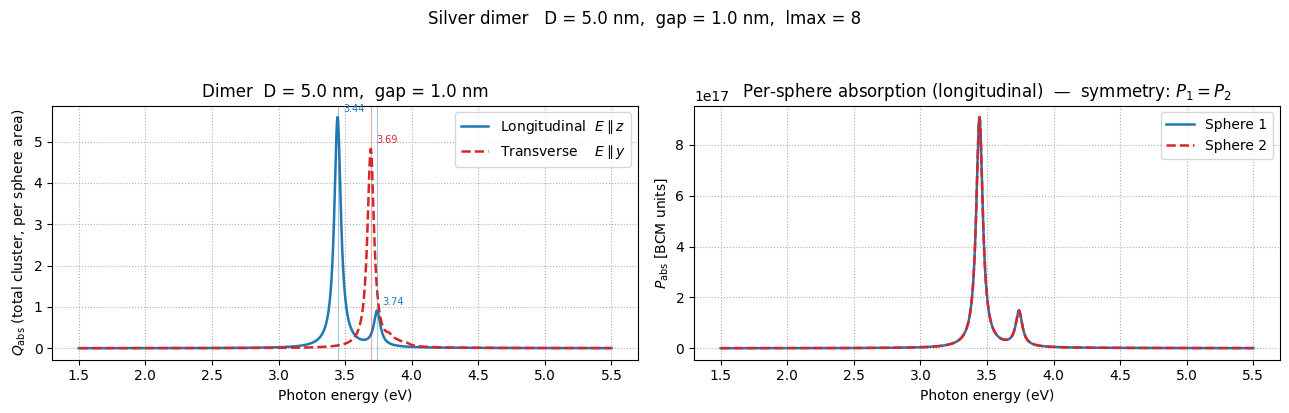

Symmetry check: Pabs1_max / Pabs2_max = 1.000000  (should be 1.0)


In [9]:
I0_d = ef_long.E0**2 / (2 * Z0)

# Total dimer absorption = sum over spheres
Qabs_l = (Pabs_l[0] + Pabs_l[1]) / I0_d / (2 * np.pi * a_dim**2)
Qabs_t = (Pabs_t[0] + Pabs_t[1]) / I0_d / (2 * np.pi * a_dim**2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# -- Left: longitudinal vs transverse (total cluster)
ax = axes[0]
ax.plot(hv_d, Qabs_l, 'C0',   lw=1.8, label=r'Longitudinal  $E \parallel z$')
ax.plot(hv_d, Qabs_t, 'C3--', lw=1.8, label=r'Transverse    $E \parallel y$')

for Qa, col in [(Qabs_l, 'C0'), (Qabs_t, 'C3')]:
    pks, _ = find_peaks(Qa, height=0.05 * Qa.max(), prominence=0.01)
    for pk in pks:
        ax.axvline(hv_d[pk], lw=0.8, color=col, alpha=0.4)
        ax.annotate(f'{hv_d[pk]:.2f}',
                    xy=(hv_d[pk], Qa[pk]),
                    xytext=(4, 4), textcoords='offset points', fontsize=7, color=col)

ax.set_xlabel('Photon energy (eV)')
ax.set_ylabel(r'$Q_{\rm abs}$ (total cluster, per sphere area)')
ax.set_title(f'Dimer  D = {D_dim} nm,  gap = {gap_dim} nm')
ax.legend()
ax.grid(True, ls=':')

# -- Right: per-sphere absorption (symmetry check, longitudinal)
ax = axes[1]
ax.plot(hv_d, Pabs_l[0], 'C0',   lw=1.8, label='Sphere 1')
ax.plot(hv_d, Pabs_l[1], 'C3--', lw=1.8, label='Sphere 2')
ax.set_xlabel('Photon energy (eV)')
ax.set_ylabel(r'$P_{\rm abs}$ [BCM units]')
ax.set_title(r'Per-sphere absorption (longitudinal)  —  symmetry: $P_1 = P_2$')
ax.legend()
ax.grid(True, ls=':')

fig.suptitle(f'Silver dimer   D = {D_dim} nm,  gap = {gap_dim} nm,  lmax = {lmax_d}',
             y=1.02)
plt.tight_layout()
plt.show()

# Symmetry check
ratio = Pabs_l[0].max() / Pabs_l[1].max()
print(f'Symmetry check: Pabs1_max / Pabs2_max = {ratio:.6f}  (should be 1.0)')


---
## Step 6 - High-level API: `run_optical_response`

For routine simulations, `run_optical_response` handles the complete pipeline
(material setup, frequency range, matrix assembly, frequency sweep, power
computation, and output folder creation) from a single config dict.

```python
config = {
    'positions':  [[0, 0, 3],  [0, 0, -3]],   # sphere centres [nm]
    'diameters':  [5.0, 5.0],                  # diameters [nm]
    'materials':  ['Silver', 'Silver'],         # must be in MATERIAL_PARAMS
    'k_vec':      [1, 0, 0],                   # propagation direction
    'e_vec':      [0, 0, 1],                   # polarisation
    'eps_h':      'Vacuum \ Air',             # must be in MEDIA
    'model':      'nordlander',                # 'bulk' or 'nordlander'
}
result = bcm.run_optical_response(config, lmax=8, n_points=500)
```

It returns a dict with pre-computed `Qabs_total`, `Qsca_total`, `peak_idx_per_particle`,
an `outdir` path, and all BCMObject instances with coefficients already stored.

**When to use**: batch runs, parameter sweeps, when output folders are desired.
**When to use the manual approach**: when you need fine control (custom eps, custom
frequency range, notebook exploration).


Running run_optical_response...
Surrounding medium: Vacuum / Air  (εₕ = 1.0)
Auto energy range: 2.71 – 4.06 eV
  Silver: resonance ≈ 3.38 eV
Dielectric model: Nordlander


Assembling Gi/G0/Sv:   0%|          | 0/1 [00:00<?, ?obj/s]

Solving BCM over ω:   0%|          | 0/300 [00:00<?, ?pt/s]

Absorption peaks: 1  at λ = 339.9 nm
Saving to: c:\users\pablo\proyectos\plytrons\Results\spherical_NP\Monomer\static_simulations\monomer-single_D10.0nm_isolated_Exkz


c:\users\pablo\proyectos\plytrons\plytrons\bcm_sphere.py:251: RuntimeWarning: invalid value encountered in true_divide
  vector = np.array(vector) / np.array(vector)


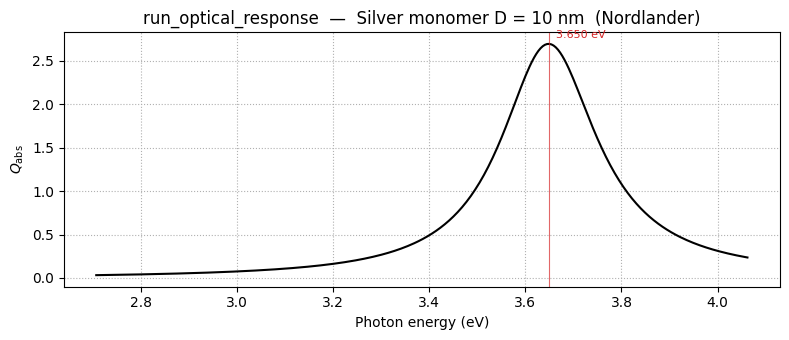

Results saved to: c:\users\pablo\proyectos\plytrons\Results\spherical_NP\Monomer\static_simulations\monomer-single_D10.0nm_isolated_Exkz
  absorption_spectrum.png
  E_eV.npy
  Qabs_total.npy
  Qsca_total.npy


In [ ]:
import os

# Minimal demonstration of run_optical_response (single sphere)
config_mono = {
    'positions':  [[0, 0, 0]],
    'diameters':  [10.0],
    'materials':  ['Silver'],
    'k_vec':      [0, 0, 1],
    'e_vec':      [1, 0, 0],
    'eps_h':      'Vacuum / Air',
    'model':      'Nordlander',
}

print('Running run_optical_response...')
result = bcm.run_optical_response(config_mono, lmax=8, n_points=300)
outdir = result['outdir']

E_eV_r   = result['E_eV']
Qabs_r   = result['Qabs_total']
pk_idx_r = result['peak_idx_total']

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(E_eV_r, Qabs_r, 'k', lw=1.5)
for pk in pk_idx_r:
    ax.axvline(E_eV_r[pk], lw=0.8, color='C3', alpha=0.7)
    ax.annotate(f'{E_eV_r[pk]:.3f} eV',
                xy=(E_eV_r[pk], Qabs_r[pk]),
                xytext=(5, 4), textcoords='offset points', fontsize=8, color='C3')
ax.set_xlabel('Photon energy (eV)')
ax.set_ylabel(r'$Q_{\rm abs}$')
ax.set_title('run_optical_response  —  Silver monomer D = 10 nm  (Nordlander)')
ax.grid(True, ls=':')
plt.tight_layout()

# ---- Save outputs to the results folder --------------------------------
np.save(outdir / 'E_eV.npy',       E_eV_r)
np.save(outdir / 'Qabs_total.npy', Qabs_r)
np.save(outdir / 'Qsca_total.npy', result['Qsca_total'])

plt.show()

print(f'Results saved to: {outdir}')
print('  absorption_spectrum.png')
print('  E_eV.npy')
print('  Qabs_total.npy')
print('  Qsca_total.npy')


---
## Summary

### Typical workflow

```
1. Define material  eps(lambda)  via Drude formula  or  MATERIAL_PARAMS
2. Define geometry  BCMObject list  (position, diameter, lmax, eps)
3. Define field     EField(E0, k_hat, e_hat)
4. Build matrices   Ginternal, Gexternal, Efield_coupling  [once]
5. Frequency loop   solve_BCM(wi, ...)  ->  store coef[:, il]
6. After loop       set_coefficients(lam_um, coef)
7. Power            EM_power  ->  Pabs, Psca
8. Access field     obj.coef_at(lam_peak)  ->  X_lm
9. Hot carriers     hot_e_dist(a, hv, EF, tau_e, e_states, X_lm, Pabs_eVfs)
```

### Choosing $\ell_{\max}$

| Diameter | Recommended $\ell_{\max}$ |
|---|---|
| $D < 5$ nm | 4 – 6 |
| $5 \leq D \leq 15$ nm | 6 – 8 |
| $D > 15$ nm | 8 – 12 |
| Dimer / cluster | +2 above monomer value |

### Connection to the rest of the pipeline

```
bcm_sphere.py    solve_BCM + EM_power  -->  X_lm, Pabs
drude_model.py   eps_drude_*           -->  eps(omega)   [input to BCMObject.eps]
                                             |
hot_carriers.py  hot_e_dist(...)       -->  Te_raw, Th_raw
HC_spatial.py    hot_e_dist_spatial    -->  n_e(r),  rho_e(r,theta)
relaxation.py    effective_lifetime    -->  tau_ee, tau_eph
```
